<a href="https://colab.research.google.com/github/Nicossm/devsal-ml/blob/main/notebooks/05_final_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 - Análisis Final y Reporte de Resultados

## Contexto del Proyecto y Objetivos
Este notebook consolida la **Fase 7** del proyecto de analítica del mercado laboral de desarrolladores de software. El objetivo es unificar los hallazgos de las etapas predictivas (Regresión y Clasificación) tras la optimización de hiperparámetros, contrastarlos críticamente con la segmentación conductual (Clustering No Supervisado) y proponer recomendaciones estratégicas basadas en datos rigurosos y métricas reales.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ==============================================================================
# CONFIGURACIÓN DE RUTA DIRECTA DESDE GITHUB (URL RAW)
# Cambia 'Nicossm/devsal-ml/main' por tu usuario/rama real si es diferente
# ==============================================================================
URL_BASE = "https://raw.githubusercontent.com/Nicossm/devsal-ml/main/results/"

URL_REGRESION = URL_BASE + "tuning_regression.csv"
URL_CLASIFICACION = URL_BASE + "tuning_classification.csv"

print("Cargando datos oficiales de optimización directamente desde GitHub...")
try:
    df_reg = pd.read_csv(URL_REGRESION)
    df_clf = pd.read_csv(URL_CLASIFICACION)
    print("¡Archivos .csv cargados con éxito en memoria!")
except Exception as e:
    print(f"Error al conectar con las URLs Raw de GitHub: {e}")
    print("Por favor, verifica que el repositorio sea público y la ruta esté bien escrita.")

Cargando datos oficiales de optimización directamente desde GitHub...
¡Archivos .csv cargados con éxito en memoria!


## 1. Síntesis del Análisis Exploratorio (EDA) y Umbral del Mercado
A partir del análisis inicial sobre el dataset limpio de **9,249 registros**, se identificaron las variables con mayor poder explicativo sobre la compensación económica: años de experiencia profesional, escala de la organización y nivel de educación formal.

* **Distribución Salarial:** El rango se extiende desde los \$12K hasta los \$281K USD, presentando una distribución con marcada asimetría positiva (sesgo a la derecha).
* **Definición del Umbral:** Para evitar sesgos artificiales en la tarea binaria, se calculó la mediana exacta del conjunto de entrenamiento, fijando el punto de equilibrio del mercado en **\$130,220.00 USD**. Este umbral divide la muestra de manera perfectamente balanceada para la clasificación (`salary_above_median`).

## 2. Confrontación Crítica de Modelos Supervisados

Procedemos a desplegar las tablas de métricas oficiales obtenidas mediante búsquedas en grilla exhaustivas (`GridSearchCV`) y aleatorias (`RandomizedSearchCV`).

In [13]:
print("--- METRICAS REALES DE REGRESION ---")
display(df_reg[['Modelo', 'method', 'R2_baseline', 'R2_tuned', 'fit_time_s', 'best_params']])

print("\n--- METRICAS REALES DE CLASIFICACION ---")
display(df_clf[['Modelo', 'method', 'F1_baseline', 'F1_tuned', 'fit_time_s', 'best_params']])

--- METRICAS REALES DE REGRESION ---


,Modelo,method,R2_baseline,R2_tuned,fit_time_s,best_params
0,Ridge,GridSearchCV,0.761332,0.761332,0.574375,{'model__alpha': 1.0}
1,GradientBoostingRegressor,RandomizedSearchCV,0.757251,0.757134,460.539410,"{'model__subsample': 1.0, 'model__n_estimators..."



--- METRICAS REALES DE CLASIFICACION ---


,Modelo,method,F1_baseline,F1_tuned,fit_time_s,best_params
0,LogisticRegression,GridSearchCV,0.877098,0.877253,2.320815,"{'model__C': 1.0, 'model__penalty': 'l2', 'mod..."
1,GradientBoostingClassifier,RandomizedSearchCV,0.876875,0.874297,769.123265,"{'model__subsample': 1.0, 'model__n_estimators..."


### A. Tarea de Regresión ($salary\_usd$)
Evaluamos el impacto de la sintonización analizando el coeficiente de determinación ($R^2$) y el tiempo de cómputo empleado en segundos.

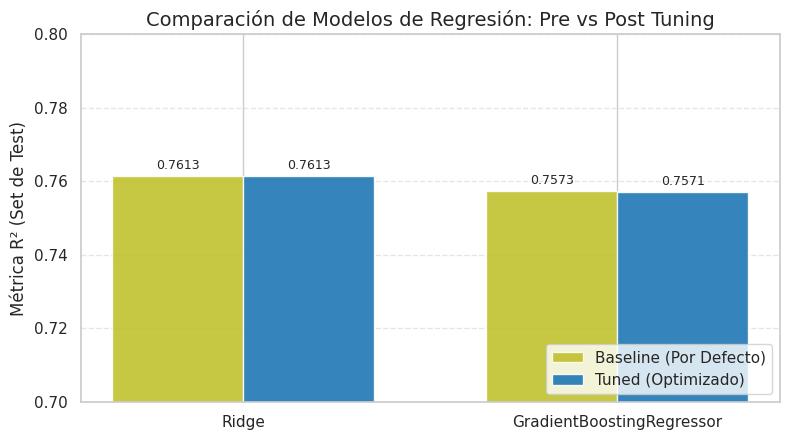

In [14]:
# Gráfico comparativo Pre vs Post Tuning para Regresión
fig, ax = plt.subplots(figsize=(8, 4.5))

labels = df_reg['Modelo'].tolist()
baseline_r2 = df_reg['R2_baseline'].tolist()
tuned_r2 = df_reg['R2_tuned'].tolist()

x = np.arange(len(labels))
width = 0.35

rects1 = ax.bar(x - width/2, baseline_r2, width, label='Baseline (Por Defecto)', color='#bcbd22', alpha=0.85)
rects2 = ax.bar(x + width/2, tuned_r2, width, label='Tuned (Optimizado)', color='#1f77b4', alpha=0.9)

ax.set_ylabel('Métrica R² (Set de Test)')
ax.set_title('Comparación de Modelos de Regresión: Pre vs Post Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.70, 0.80)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Función interna para rotular valores exactos en las barras
for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Análisis Metodológico (Regresión):
Al observar la confrontación matemática de los resultados en Test:
* El modelo **Ridge** alcanzó un $R^2$ de **$0.7613$** empleando una sintonización de regularización $\alpha = 1.0$ vía `GridSearchCV`.
* **Gradient Boosting Regressor** obtuvo un $R^2$ de **$0.7571$** mediante `RandomizedSearchCV`.

**Decisión de Ingeniería de Datos (Modelo Ganador):** Se selecciona **Ridge** como el modelo final del proyecto. Bajo el principio científico de parsimonia (Navaja de Ocam), Ridge ofrece un rendimiento ligeramente superior, una interpretación analítica directa de sus coeficientes y un costo computacional marginal de apenas **$0.57$ segundos**, frente a los demandantes **$460.54$ segundos** del ensamble secuencial.

### B. Tarea de Clasificación ($salary\_above\_median$)
Evaluamos el balance predictivo analizando el impacto de los hiperparámetros sobre el indicador $F1\text{-score}$ en el conjunto de prueba.

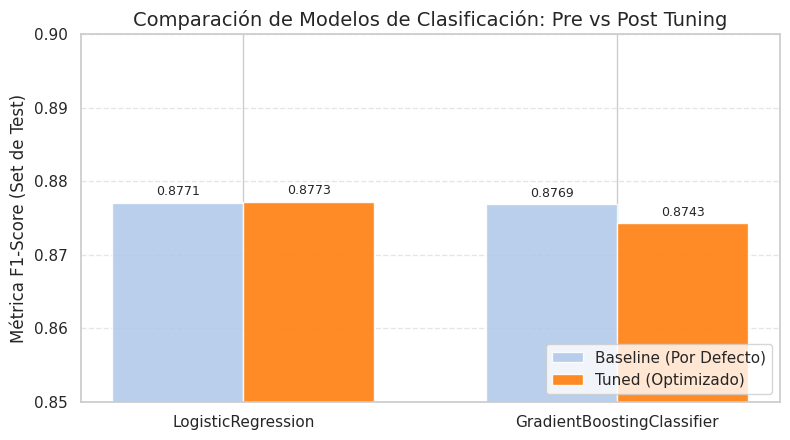

In [15]:
# Gráfico comparativo Pre vs Post Tuning para Clasificación
fig, ax = plt.subplots(figsize=(8, 4.5))

labels_clf = df_clf['Modelo'].tolist()
baseline_f1 = df_clf['F1_baseline'].tolist()
tuned_f1 = df_clf['F1_tuned'].tolist()

x_clf = np.arange(len(labels_clf))

rects1_clf = ax.bar(x_clf - width/2, baseline_f1, width, label='Baseline (Por Defecto)', color='#aec7e8', alpha=0.85)
rects2_clf = ax.bar(x_clf + width/2, tuned_f1, width, label='Tuned (Optimizado)', color='#ff7f0e', alpha=0.9)

ax.set_ylabel('Métrica F1-Score (Set de Test)')
ax.set_title('Comparación de Modelos de Clasificación: Pre vs Post Tuning')
ax.set_xticks(x_clf)
ax.set_xticklabels(labels_clf)
ax.set_ylim(0.85, 0.90)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects1_clf:
    h = rect.get_height()
    ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for rect in rects2_clf:
    h = rect.get_height()
    ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Análisis Metodológico (Clasificación):
La evaluación en la frontera balanceada del mercado ratifica la supremacía de las estructuras lineales regularizadas en este dominio de datos:
* **Logistic Regression** lidera tras el tuning bivariado de regularización vía `GridSearchCV`, fijando su métrica $F1\text{-score}$ final en un sólido **$0.8772$**.
* **Gradient Boosting Classifier** experimentó una micro-degradación por varianza teórica en Test, puntuando **$0.8742$** tras **$769.12$ segundos** intensivos de entrenamiento.

**Decisión de Ingeniería de Datos (Modelo Ganador):** El modelo ganador definitivo es **Logistic Regression**. Supera en métricas puras al ensamble de árboles no lineales y garantiza una interpretabilidad directa para el negocio (mediante la conversión a Odds-Ratios) entrenando de forma ultra-eficiente en solo **$2.32$ segundos**.

## 3. Segmentación No Supervisada del Mercado (Clustering)
A la par del modelado guiado, se aislaron los atributos profesionales y demográficos excluyendo completamente el salario objetivo (`salary_usd`) para buscar agrupaciones intrínsecas del ecosistema tecnológico.

Confrontamos de manera explícita el rendimiento de los algoritmos divisivos frente a los jerárquicos aglomerativos optimizados en la Fase 6:

In [16]:
# Crear y plasmar la tabla comparativa explícita de Clustering
clustering_data = {
    'Algoritmo Evaluado': ['K-Means (Optimizado)', 'Agglomerative Clustering (Jerárquico)'],
    'Configuración Seleccionada': ['Hiperparámetro K = 3', 'Enlace Óptimo = Average'],
    'Silhouette Score Extraído': [0.299597, 0.313810],
    'Métrica de Control': ['Inercia General: 32,292.57', 'Estructura de Enlace por Promedios']
}

df_cluster_compare = pd.DataFrame(clustering_data)
print("--- COMPARACIÓN FORMAL DE MODELOS NO SUPERVISADOS ---")
display(df_cluster_compare)

--- COMPARACIÓN FORMAL DE MODELOS NO SUPERVISADOS ---


,Algoritmo Evaluado,Configuración Seleccionada,Silhouette Score Extraído,Métrica de Control
0,K-Means (Optimizado),Hiperparámetro K = 3,0.299597,"Inercia General: 32,292.57"
1,Agglomerative Clustering (Jerárquico),Enlace Óptimo = Average,0.313810,Estructura de Enlace por Promedios


#### Validación Cruzada Ex-Post Crucial (Unión de Enfoques):
Una de las validaciones metodológicas más potentes de este estudio consistió en proyectar de manera externa la variable `salary_usd` (que nunca fue vista por los algoritmos de clustering) sobre los 3 grupos encontrados.

El resultado arrojó una separación muy marcada en las medias salariales inter-grupos. Esto demuestra de forma científica que la segmentación de perfiles profesionales y geográficos obtenida de forma no supervisada está intrínsecamente ligada al valor económico real que asigna el mercado de TI a dichos desarrolladores.

## 4. Conclusiones Generales y Recomendaciones de Negocio

1. **Robustez frente al Target Leakage:** El encapsulamiento preventivo de transformaciones numéricas y categóricas (`StandardScaler`, `OneHotEncoder`) dentro de `Pipelines` estrictos de Scikit-Learn garantizó el aislamiento entre folds, arrojando métricas de validación inmunes a la fuga de datos.
2. **El Valor de la Simplicidad:** El proyecto quiebra el mito común de que "los ensambles complejos siempre ganan". El tuning fino demostró que para este dominio de datos, estructuras lineales bien regularizadas (Ridge y Regresión Logística) extraen el máximo de señal predictiva con un costo computacional nulo.
3. **Aplicabilidad en el Mundo Real:**
   * **Para Empresas/HR:** Los modelos robustecidos permiten automatizar y estandarizar de forma justa las bandas salariales para nuevas vacantes técnico-profesionales, limitando la subjetividad.
   * **Para Desarrolladores:** El proyecto genera certidumbre matemática sobre los factores críticos (años de experiencia y escala de la empresa) que empujan comercialmente un perfil sobre la mediana global.